In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

gen_results = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results/real_samples.npz')
conditional_inputs = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results/conditional_inputs.npz')
training_testing_data = np.load('/Users/isaaclee/Wildfire_Research/data/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy')
testing_data = training_testing_data[-1200:]

print(gen_results.files)
print(gen_samples.files)
print(real_samples.files)
print(conditional_inputs.files)
print(training_testing_data.shape)
print(testing_data.shape)


['array1', 'array2']
['arr_0']
['arr_0']
['arr_0']
(15200, 24)
(1200, 24)


# Evaluating model accuracy

In [64]:
real = real_samples['arr_0']
pred = gen_results['array1']
print(real.shape)
print(pred.shape)

stds = gen_results['array2']

print(pred.shape)
print(stds.shape)

print(np.mean(stds.flatten())*50000)

mae = np.mean(np.abs(real-pred))
print("Mean Absolute Error: " + str(mae))

normalized_mae = mae/np.mean(real)
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))

(1200, 1)
(1200, 1)
(1200, 1)
(1200, 1)
970.5175088408093
Mean Absolute Error: 0.04053448680583339
Normalized Mean Absolute Error: 0.6376121515996404
Mean Absolute Percent Error: 1.3471307054601118


(1200000,)
(1200,)


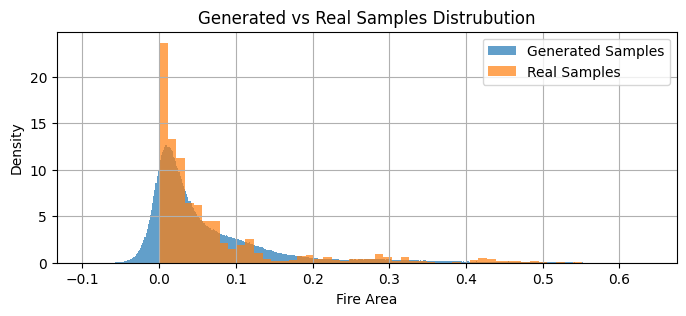

In [65]:
gen = gen_samples['arr_0'].flatten()
real = real_samples['arr_0'].flatten()

print(gen.shape)
print(real.shape)

plt.figure(figsize=(8,3))
plt.title('Generated vs Real Samples Distrubution')
plt.hist(gen, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

(1200,)
(1200,)


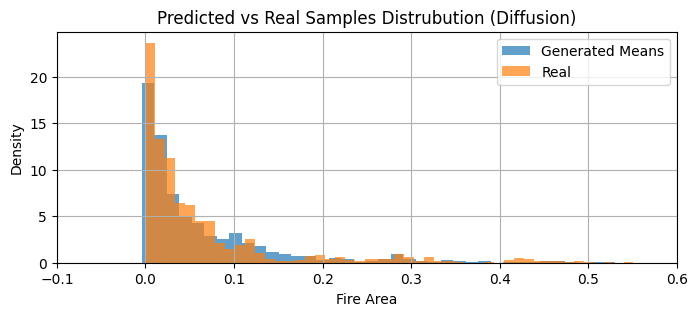

In [66]:
gen = gen_results['array1'].flatten()

print(gen.shape)
print(real.shape)

plt.figure(figsize=(8,3))
plt.title('Predicted vs Real Samples Distrubution (Diffusion)')
plt.hist(gen, bins='auto', alpha=0.7, label='Generated Means', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.xlim((-0.1, 0.6))
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [67]:
gen_all = gen_samples['arr_0'].reshape(1200, 1000)
means = gen_results['array1']
stds = gen_results['array2']
real = real_samples['arr_0']

indices = np.where(np.abs(real-means) < stds)[0]
indices_2 = np.where(np.abs(real-means) < 2*stds)[0]

print(len(indices)/len(real.flatten()))
print(len(indices_2)/len(real.flatten()))

0.5941666666666666
0.7575


In [68]:
print(testing_data.shape)
print(gen_all.shape)

time = 6/50
tol = 2/50
indices = np.where(np.abs(testing_data[:, 1] - time) <= tol)[0]
filtered_testing_data = testing_data[indices]
filtered_gen_dist = gen_all[indices]

print(filtered_testing_data.shape)
print(filtered_gen_dist.shape)

(1200, 24)
(1200, 1000)
(102, 24)
(102, 1000)


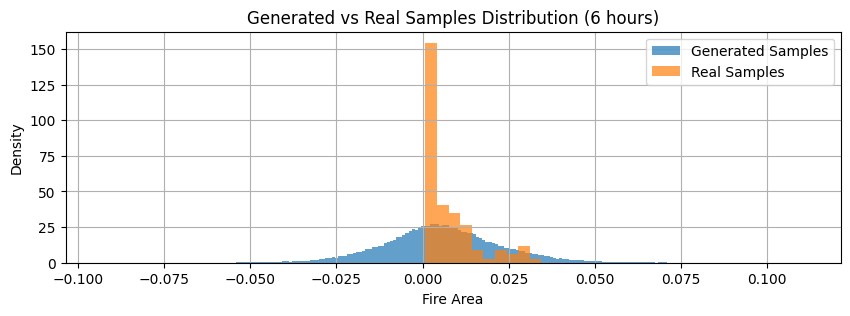

In [69]:
plt.figure(figsize=(10,3))
plt.title('Generated vs Real Samples Distribution (6 hours)')
plt.hist(filtered_gen_dist.flatten(), bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real[indices], bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [70]:
# Finding largest fire

conditional_data = conditional_inputs['arr_0']

base_case_indices = np.arange(0, 1200, 100)
original_conditions = conditional_data[base_case_indices]

col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y",
            "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6",
            "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
test_df = pd.DataFrame(testing_data, columns=col_names)

test_df['fire_area'] = test_df['fire_area'] * 50000

fire_areas = test_df['fire_area']
max_area_index = np.where(fire_areas == max(fire_areas))[0]
max_ind = max_area_index[0]
print(max_ind) # 976
print(test_df['fire_area'][max_ind])

max_set_start = (max_ind // 100) * 100
max_set_end = min(((max_ind+99)//100) * 100, len(test_df))

max_set = test_df[max_set_start:max_set_end]

time = 36/50
tol = 0.1/50
i = np.where(np.abs(max_set['forecast_len'] - time) <= tol)[0]

print(i.shape)
i = i[0]

976
27548.543455589886
(1,)


In [71]:
max_set

,fire_area,forecast_len,u,v,humidity,temp,terrain_x,terrain_y,terrain_var,terrain_RMS,...,fuel5,fuel6,fuel7,fuel8,fuel9,fuel10,fuel11,fuel12,fuel13,fuel14
900,20746.658948,0.771212,0.363674,0.619646,0.326210,0.772236,0.687704,0.741148,0.509908,0.604989,...,0.380284,0.000041,0.008489,0.024947,0.010692,0.009347,0.0,0.0,0.0,0.051005
901,15656.751412,0.589262,0.363674,0.619646,0.326210,0.772236,0.687704,0.741148,0.509908,0.604989,...,0.380284,0.000041,0.008489,0.024947,0.010692,0.009347,0.0,0.0,0.0,0.051005
902,3224.725228,0.293904,0.363674,0.619646,0.326210,0.772236,0.687704,0.741148,0.509908,0.604989,...,0.380284,0.000041,0.008489,0.024947,0.010692,0.009347,0.0,0.0,0.0,0.051005
903,14600.684788,0.557848,0.363674,0.619646,0.326210,0.772236,0.687704,0.741148,0.509908,0.604989,...,0.380284,0.000041,0.008489,0.024947,0.010692,0.009347,0.0,0.0,0.0,0.051005
904,21502.029211,0.808964,0.363674,0.619646,0.326210,0.772236,0.687704,0.741148,0.509908,0.604989,...,0.380284,0.000041,0.008489,0.024947,0.010692,0.009347,0.0,0.0,0.0,0.051005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5527.129621,0.372356,0.389578,0.355230,0.325879,0.772386,0.734908,0.272505,0.503830,0.587670,...,0.384272,0.000050,0.007619,0.025695,0.009712,0.008122,0.0,0.0,0.0,0.051144
996,22731.224043,0.853106,0.389578,0.355230,0.325879,0.772386,0.734908,0.272505,0.503830,0.587670,...,0.384272,0.000050,0.007619,0.025695,0.009712,0.008122,0.0,0.0,0.0,0.051144
997,17901.394921,0.644558,0.389578,0.355230,0.325879,0.772386,0.734908,0.272505,0.503830,0.587670,...,0.384272,0.000050,0.007619,0.025695,0.009712,0.008122,0.0,0.0,0.0,0.051144
998,21953.459855,0.819621,0.389578,0.355230,0.325879,0.772386,0.734908,0.272505,0.503830,0.587670,...,0.384272,0.000050,0.007619,0.025695,0.009712,0.008122,0.0,0.0,0.0,0.051144


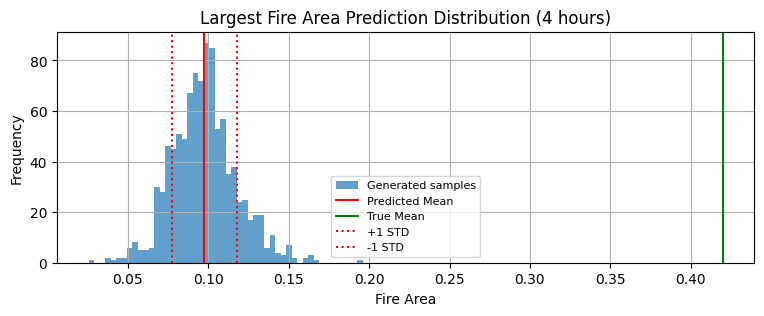

In [72]:
plt.figure(figsize=(9,3))
plt.title('Largest Fire Area Prediction Distribution (4 hours)')
plt.hist(gen_all[i+max_set_start], bins=50, alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[i+max_set_start], color='red', label='Predicted Mean')
plt.axvline(real[i+max_set_start], color='green', label='True Mean')
plt.axvline(means[i+max_set_start]+stds[i+max_set_start], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[i+max_set_start]-stds[i+max_set_start], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

In [73]:
# looking for 6-8k acres after 48 hours (medium)

time = 48/50
tol = 0/50

forecast_lens = test_df['forecast_len']
med_area_ind = np.where((fire_areas < 7175) & (fire_areas > 6825) & (np.abs(forecast_lens-time <= tol)))[0][0]

print(med_area_ind)
print(test_df['fire_area'][med_area_ind])

med_set_start = (med_area_ind // 100) * 100
med_set_end = min(((med_area_ind+99)//100) * 100, len(test_df))

med_set = test_df[med_set_start:med_set_end]

time = 4/50
tol = 0.2/50
i = np.where(np.abs(med_set['forecast_len'] - time) <= tol)[0]

print(i.shape)
i = i[0]

1064
6825.822841114872
(1,)


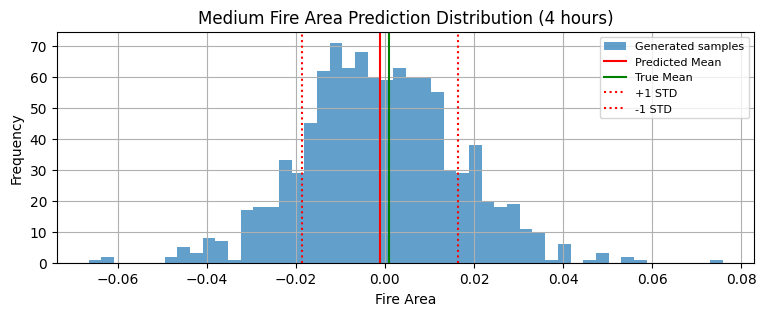

In [74]:
plt.figure(figsize=(9,3))
plt.title('Medium Fire Area Prediction Distribution (4 hours)')
plt.hist(gen_all[i+med_set_start], bins=50, alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[i+med_set_start], color='red', label='Predicted Mean')
plt.axvline(real[i+med_set_start], color='green', label='True Mean')
plt.axvline(means[i+med_set_start]+stds[i+med_set_start], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[i+med_set_start]-stds[i+med_set_start], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

In [75]:
# looking for 3k acres after 48 hours (small)

time = 48/50
tol = 0/50

forecast_lens = test_df['forecast_len']
small_area_ind = np.where((fire_areas < 3002) & (fire_areas > 2998) & (np.abs(forecast_lens-time <= tol)))[0][0]

print(small_area_ind)

print(test_df['fire_area'][small_area_ind])

small_set_start = (small_area_ind // 100) * 100
small_set_end = min(((small_area_ind+99)//100) * 100, len(test_df))

small_set = test_df[small_set_start:small_set_end]

time = 4/50
tol = 0.3/50
i = np.where(np.abs(small_set['forecast_len'] - time) <= tol)[0]

print(i.shape)
i = i[0]

761
3001.7126216690867
(1,)


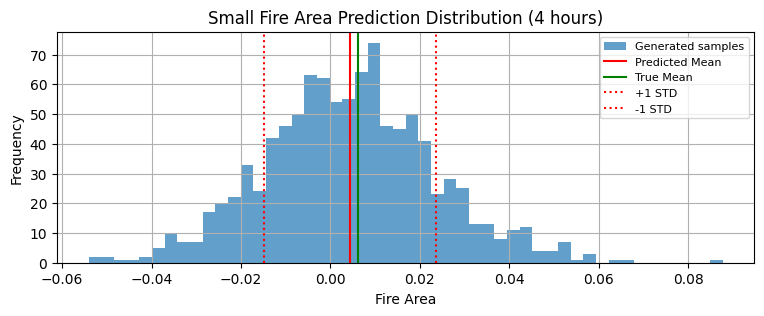

In [76]:
plt.figure(figsize=(9,3))
plt.title('Small Fire Area Prediction Distribution (4 hours)')
plt.hist(gen_all[i+small_set_start], bins=50, alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[i+small_set_start], color='red', label='Predicted Mean')
plt.axvline(real[i+small_set_start], color='green', label='True Mean')
plt.axvline(means[i+small_set_start]+stds[i+small_set_start], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[i+small_set_start]-stds[i+small_set_start], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

In [77]:
# Proportion within 1 std

within_1_std = np.abs(real - means) <= stds
proportions = within_1_std.astype(int)
print(np.mean(proportions))

0.5941666666666666


(1200,)
(1200,)


Text(0, 0.5, 'Percent error')

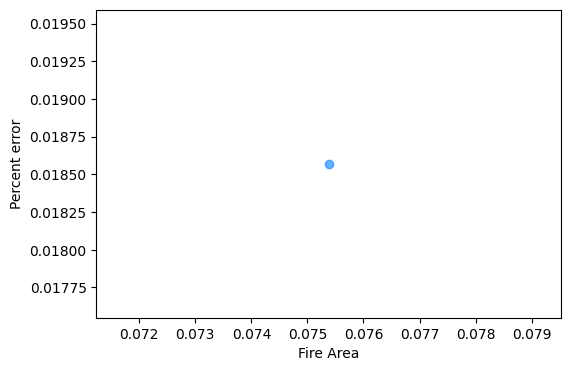

In [78]:
error = np.abs(real-pred).flatten()
# need to calculate percent error

pred_mean_areas = gen_results['array1'].flatten()

print(gen.shape)
print(error.shape)

plt.figure(figsize=(6,4))
plt.scatter(pred_mean_areas[i], error[i], color="dodgerblue", alpha=0.7)
plt.xlabel('Fire Area')
plt.ylabel('Percent error')


# Forecast Length on Model Accuracy

0.063572325
(1200, 1)


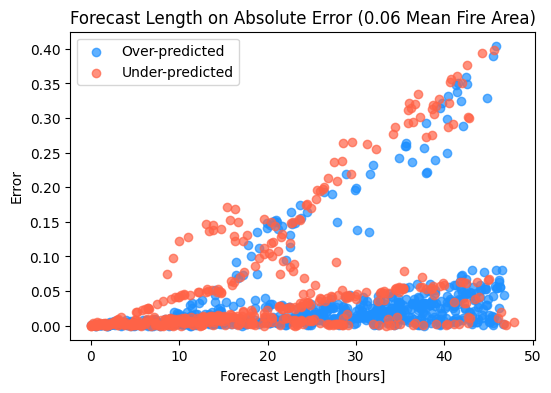

In [79]:
real = real_samples['arr_0']
print(np.mean(real))
abs_error = np.abs(real-pred)
print(abs_error.shape)
forecast_len = testing_data[:,1]
error_columns = ['forecast_len', 'error']
error_data = pd.DataFrame(np.column_stack((forecast_len*50, abs_error)),columns=error_columns)

over = np.where(pred >real)[0]
under = np.where(pred < real)[0]

plt.figure(figsize=(6,4))
plt.scatter(error_data['forecast_len'][over], error_data['error'][over], color='dodgerblue', label='Over-predicted', alpha=0.7)
plt.scatter(error_data['forecast_len'][under], error_data['error'][under], color='tomato', label='Under-predicted', alpha=0.7)
plt.title('Forecast Length on Absolute Error (0.06 Mean Fire Area)')
plt.xlabel('Forecast Length [hours]')
plt.ylabel('Error')
plt.legend()
plt.show()

Text(0, 0.5, 'Percent error')

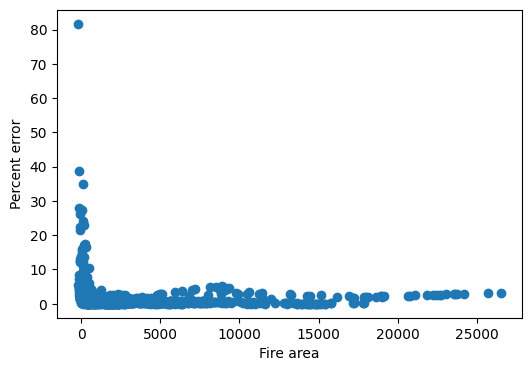

In [80]:
percent_error = np.abs(real-pred)/real
fire_area = pred * 50000

plt.figure(figsize=(6,4))
plt.scatter(fire_area, percent_error)
plt.xlabel('Fire area')
plt.ylabel('Percent error')

(1200, 1)
(1200, 1)
1.3471307054601118


Text(0, 0.5, 'Percent Error [%]')

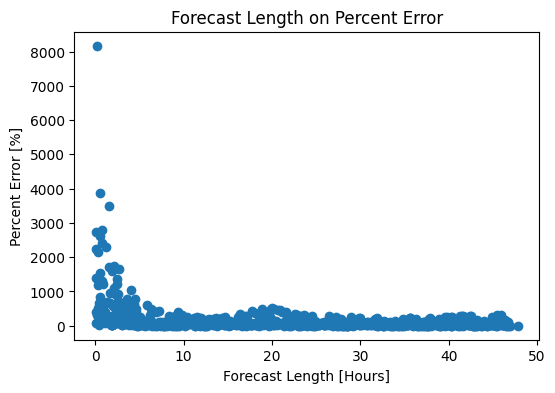

In [81]:
print(abs_error.shape)
print(real.shape)

normalized_abs_error = abs_error / np.abs(real)
print(np.mean(normalized_abs_error))
error_columns = ['forecast_len', 'normalized_error']
normalized_error_data = pd.DataFrame(np.column_stack((forecast_len*50, normalized_abs_error)),columns=error_columns)

plt.figure(figsize=(6,4))
plt.scatter(normalized_error_data['forecast_len'], normalized_error_data['normalized_error']*100)
plt.title('Forecast Length on Percent Error')
plt.xlabel('Forecast Length [Hours]')
plt.ylabel('Percent Error [%]')

## Analyzing outliers

In [82]:
threshold = 20
outlier_indices = np.where(normalized_error_data['normalized_error'] >= threshold)[0]
print(outlier_indices.size)

col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
outlier_data = pd.DataFrame(testing_data[outlier_indices], columns=col_names)

non_outlier_indices = np.where(normalized_error_data['normalized_error'] < threshold)[0]
print(non_outlier_indices.size)
non_outlier_data = pd.DataFrame(testing_data[non_outlier_indices], columns=col_names)

print(forecast_len[outlier_indices])

10
1190
[0.03191554 0.00160575 0.00092478 0.02437082 0.01609795 0.01501512
 0.00727785 0.00515958 0.01069939 0.01057911]


In [83]:
print("Outlier mean forecast_len: ", outlier_data['forecast_len'].mean()*50)
print("Non-outlier mean forecast_len: ", non_outlier_data['forecast_len'].mean()*50)
print()
print("Outlier mean humidity: ", outlier_data['humidity'].mean())
print("Non-outlier mean humidity: ", non_outlier_data['humidity'].mean())
print()
print("Outlier mean temp: ", outlier_data['temp'].mean())
print("Non-outlier mean temp: ", non_outlier_data['temp'].mean())
print()
print("Outlier mean fuel7: ", outlier_data['fuel7'].mean())
print("Non-outlier mean fuel7: ", non_outlier_data['fuel7'].mean())


Outlier mean forecast_len:  0.6182294042082503
Non-outlier mean forecast_len:  23.08583030453198

Outlier mean humidity:  0.2844176709651947
Non-outlier mean humidity:  0.31874055831121795

Outlier mean temp:  0.642409372329712
Non-outlier mean temp:  0.626063296875032

Outlier mean fuel7:  0.00015484374706602465
Non-outlier mean fuel7:  0.0012827717851606592


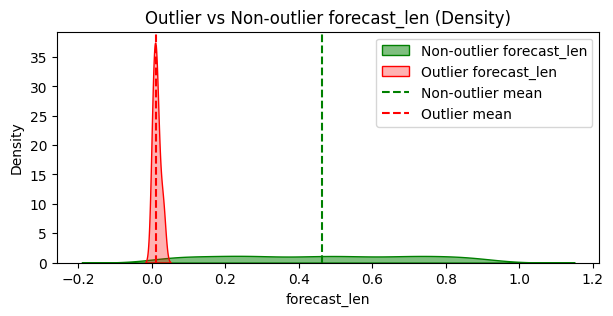

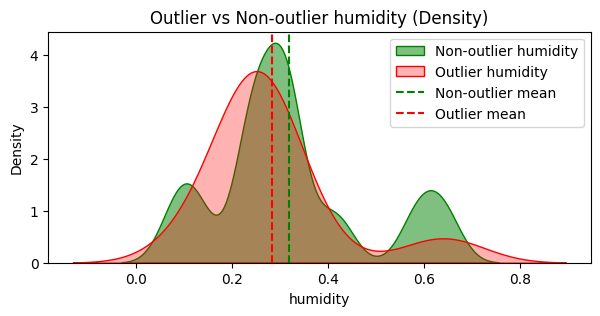

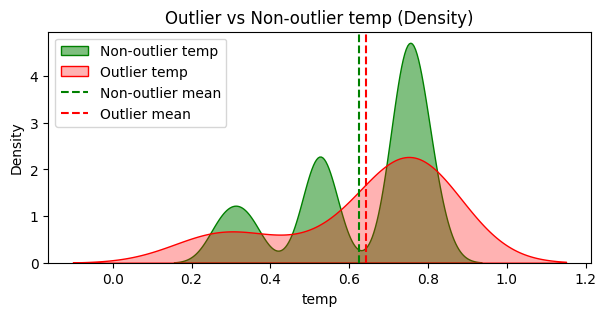

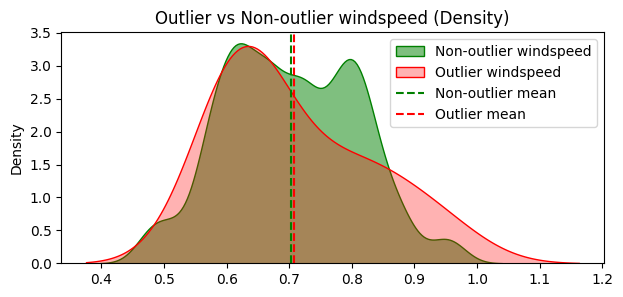

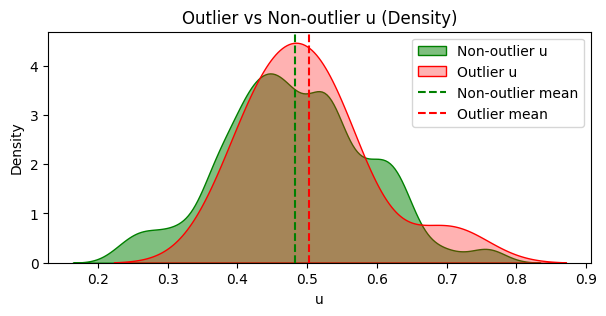

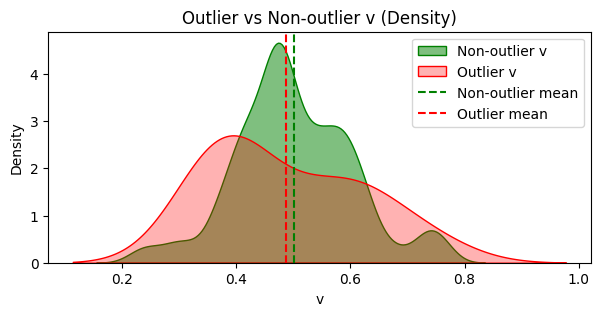

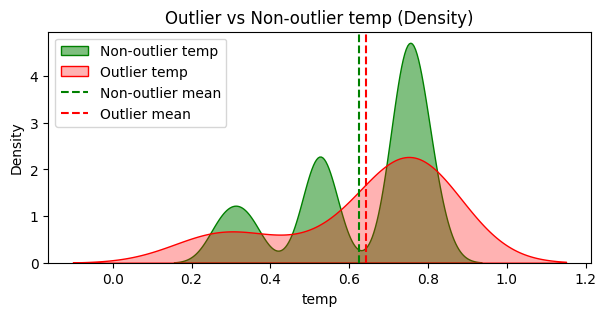

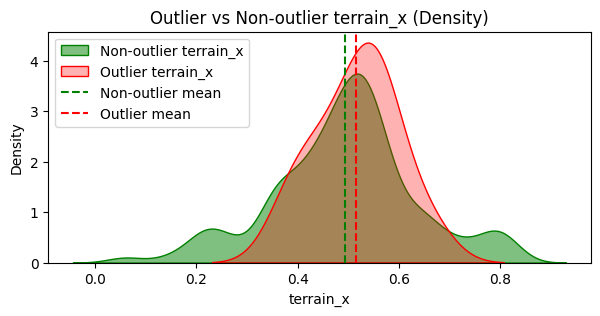

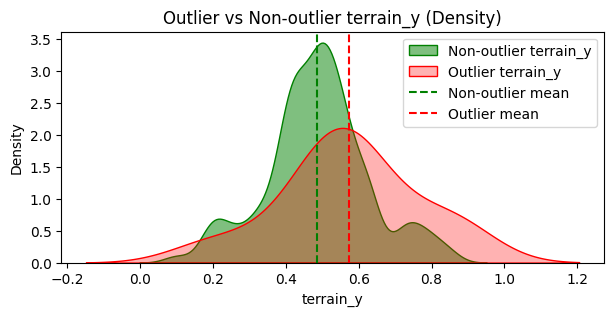

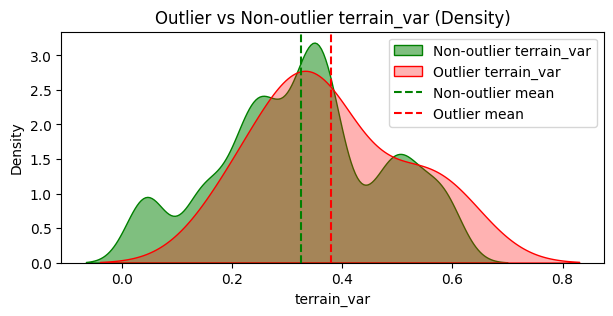

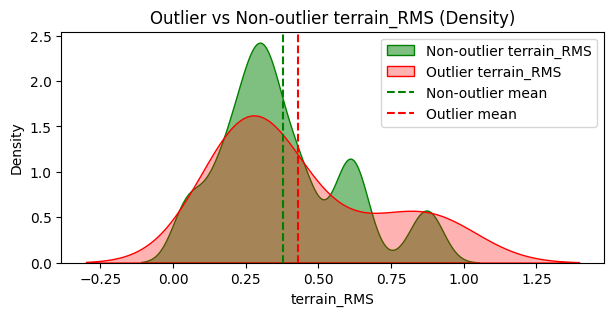

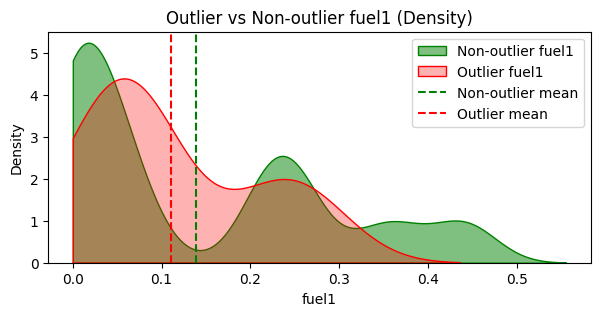

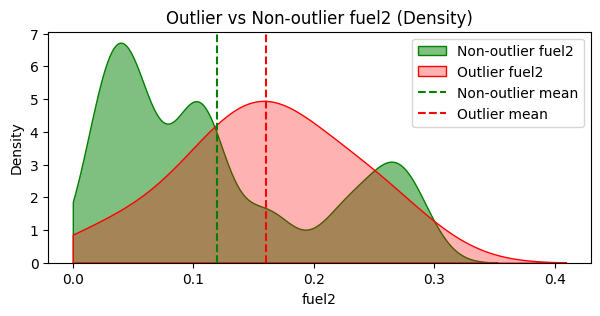

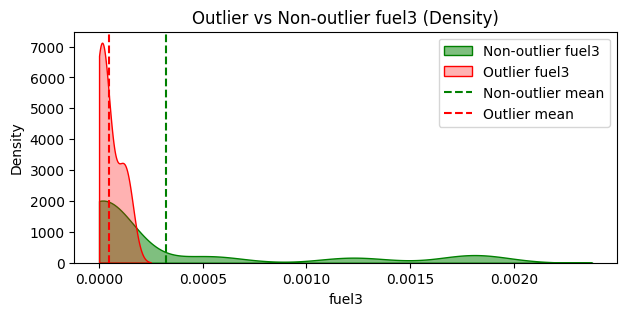

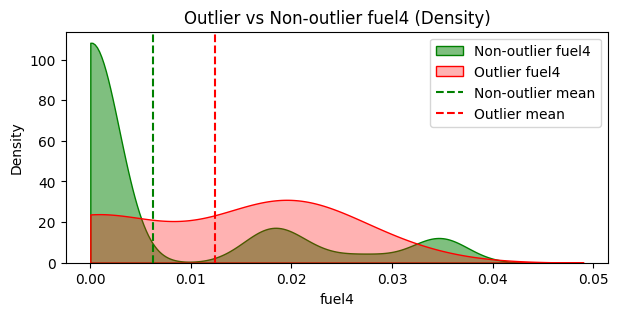

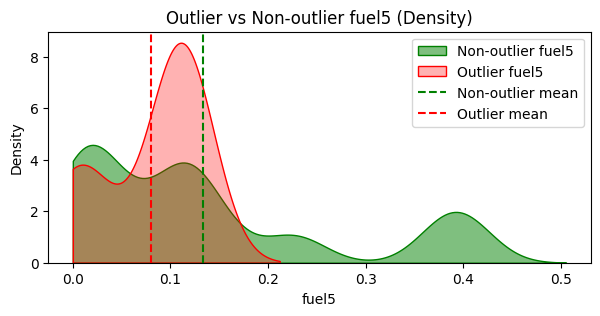

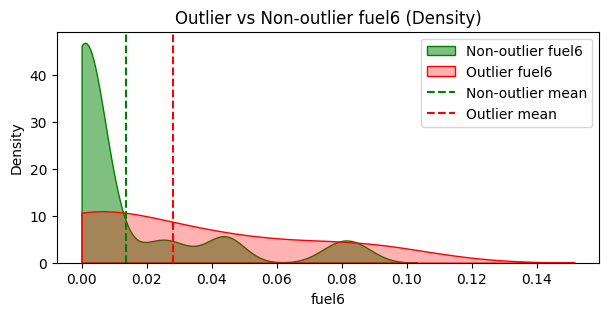

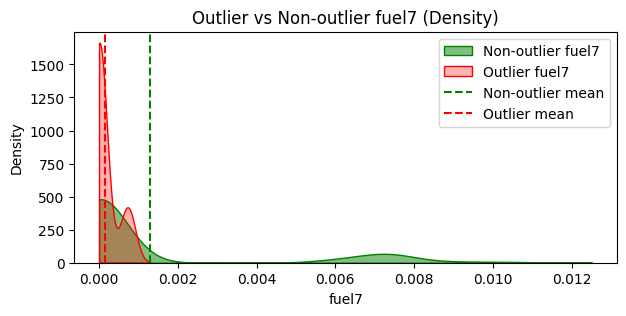

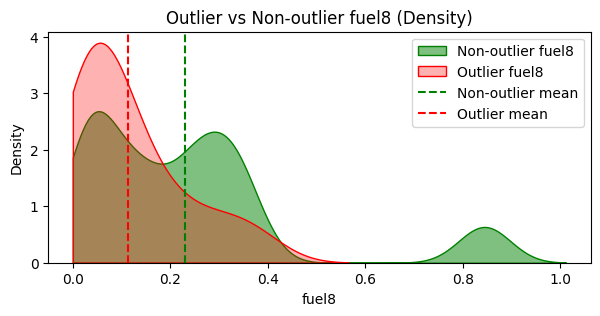

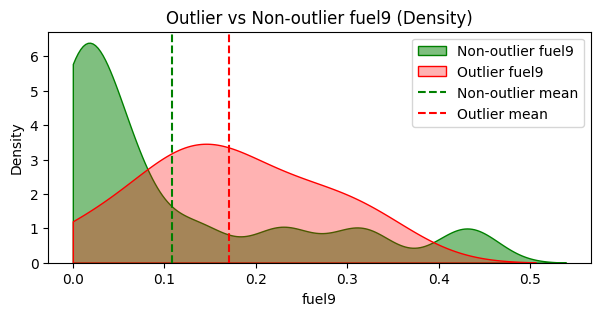

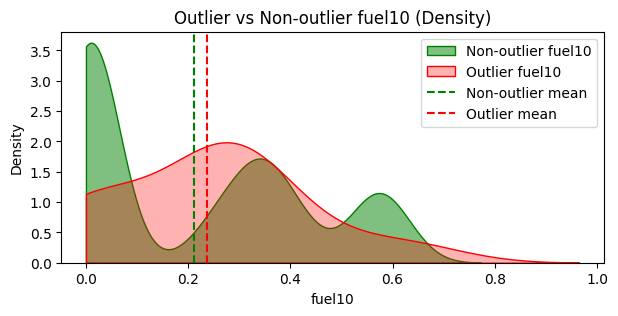

/var/folders/xq/8_lvf7nn62dfrfrb5mr1w67w0000gn/T/ipykernel_26353/2390724459.py:189: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(non_outlier_data['fuel11'], fill=True, alpha=0.5, label='Non-outlier fuel11', color='green', clip=(0, None))
/var/folders/xq/8_lvf7nn62dfrfrb5mr1w67w0000gn/T/ipykernel_26353/2390724459.py:190: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outlier_data['fuel11'], fill=True, alpha=0.3, label='Outlier fuel11', color='red', clip=(0, None))


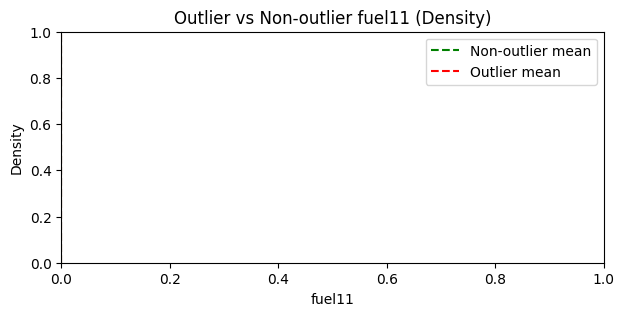

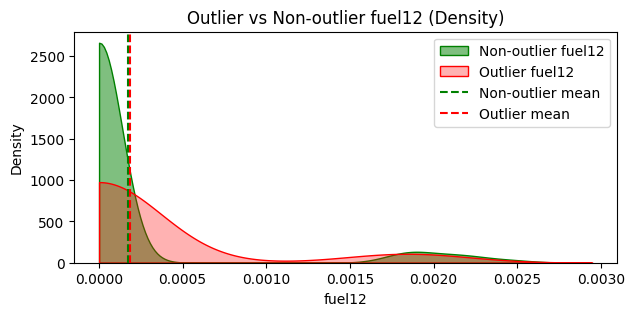

/var/folders/xq/8_lvf7nn62dfrfrb5mr1w67w0000gn/T/ipykernel_26353/2390724459.py:205: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(non_outlier_data['fuel13'], fill=True, alpha=0.5, label='Non-outlier fuel13', color='green', clip=(0, None))
/var/folders/xq/8_lvf7nn62dfrfrb5mr1w67w0000gn/T/ipykernel_26353/2390724459.py:206: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outlier_data['fuel13'], fill=True, alpha=0.3, label='Outlier fuel13', color='red', clip=(0, None))


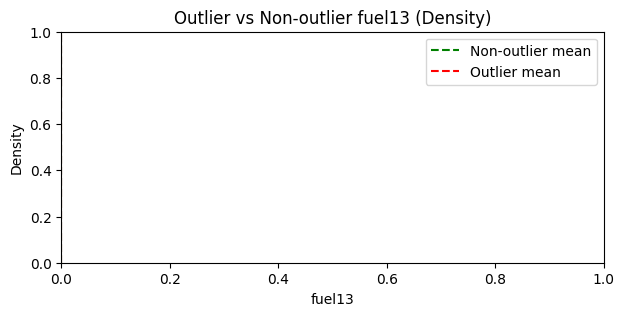

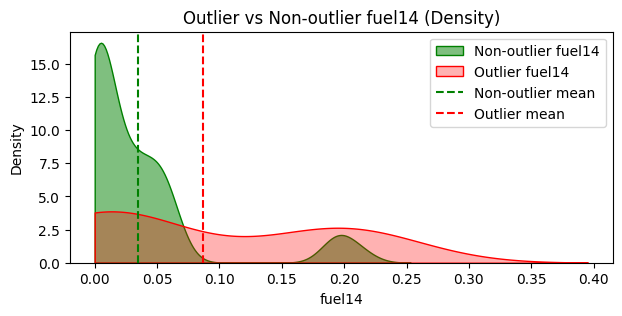

In [84]:
import seaborn as sns

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['forecast_len'], fill=True, alpha=0.5, label='Non-outlier forecast_len', color='green')
sns.kdeplot(outlier_data['forecast_len'], fill=True, alpha=0.3, label='Outlier forecast_len', color='red')
plt.axvline(non_outlier_data['forecast_len'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['forecast_len'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier forecast_len (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['humidity'], fill=True, alpha=0.5, label='Non-outlier humidity', color='green')
sns.kdeplot(outlier_data['humidity'], fill=True, alpha=0.3, label='Outlier humidity', color='red')
plt.axvline(non_outlier_data['humidity'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['humidity'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier humidity (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['temp'], fill=True, alpha=0.5, label='Non-outlier temp', color='green')
sns.kdeplot(outlier_data['temp'], fill=True, alpha=0.3, label='Outlier temp', color='red')
plt.axvline(non_outlier_data['temp'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['temp'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier temp (Density)')
plt.legend()
plt.show()

non_outlier_u = non_outlier_data['u']
non_outlier_v = non_outlier_data['v']
non_outlier_windspeed = np.sqrt(non_outlier_u**2 + non_outlier_v**2)
outlier_u = outlier_data['u']
outlier_v = outlier_data['v']
outlier_windspeed = np.sqrt(outlier_u**2 + outlier_v**2)

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_windspeed, fill=True, alpha=0.5, label='Non-outlier windspeed', color='green')
sns.kdeplot(outlier_windspeed, fill=True, alpha=0.3, label='Outlier windspeed', color='red')
plt.axvline(non_outlier_windspeed.mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_windspeed.mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier windspeed (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_u, fill=True, alpha=0.5, label='Non-outlier u', color='green')
sns.kdeplot(outlier_u, fill=True, alpha=0.3, label='Outlier u', color='red')
plt.axvline(non_outlier_u.mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_u.mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier u (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_v, fill=True, alpha=0.5, label='Non-outlier v', color='green')
sns.kdeplot(outlier_v, fill=True, alpha=0.3, label='Outlier v', color='red')
plt.axvline(non_outlier_v.mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_v.mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier v (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['temp'], fill=True, alpha=0.5, label='Non-outlier temp', color='green')
sns.kdeplot(outlier_data['temp'], fill=True, alpha=0.3, label='Outlier temp', color='red')
plt.axvline(non_outlier_data['temp'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['temp'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier temp (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['terrain_x'], fill=True, alpha=0.5, label='Non-outlier terrain_x', color='green')
sns.kdeplot(outlier_data['terrain_x'], fill=True, alpha=0.3, label='Outlier terrain_x', color='red')
plt.axvline(non_outlier_data['terrain_x'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['terrain_x'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier terrain_x (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['terrain_y'], fill=True, alpha=0.5, label='Non-outlier terrain_y', color='green')
sns.kdeplot(outlier_data['terrain_y'], fill=True, alpha=0.3, label='Outlier terrain_y', color='red')
plt.axvline(non_outlier_data['terrain_y'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['terrain_y'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier terrain_y (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['terrain_var'], fill=True, alpha=0.5, label='Non-outlier terrain_var', color='green')
sns.kdeplot(outlier_data['terrain_var'], fill=True, alpha=0.3, label='Outlier terrain_var', color='red')
plt.axvline(non_outlier_data['terrain_var'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['terrain_var'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier terrain_var (Density)')
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['terrain_RMS'], fill=True, alpha=0.5, label='Non-outlier terrain_RMS', color='green')
sns.kdeplot(outlier_data['terrain_RMS'], fill=True, alpha=0.3, label='Outlier terrain_RMS', color='red')
plt.axvline(non_outlier_data['terrain_RMS'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['terrain_RMS'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier terrain_RMS (Density)')
plt.legend()
plt.show()


plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel1'], fill=True, alpha=0.5, label='Non-outlier fuel1', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel1'], fill=True, alpha=0.3, label='Outlier fuel1', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel1'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel1'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel1 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel2'], fill=True, alpha=0.5, label='Non-outlier fuel2', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel2'], fill=True, alpha=0.3, label='Outlier fuel2', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel2'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel2'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel2 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel3'], fill=True, alpha=0.5, label='Non-outlier fuel3', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel3'], fill=True, alpha=0.3, label='Outlier fuel3', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel3'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel3'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel3 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel4'], fill=True, alpha=0.5, label='Non-outlier fuel4', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel4'], fill=True, alpha=0.3, label='Outlier fuel4', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel4'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel4'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel4 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel5'], fill=True, alpha=0.5, label='Non-outlier fuel5', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel5'], fill=True, alpha=0.3, label='Outlier fuel5', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel5'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel5'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel5 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel6'], fill=True, alpha=0.5, label='Non-outlier fuel6', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel6'], fill=True, alpha=0.3, label='Outlier fuel6', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel6'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel6'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel6 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel7'], fill=True, alpha=0.5, label='Non-outlier fuel7', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel7'], fill=True, alpha=0.3, label='Outlier fuel7', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel7'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel7'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel7 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel8'], fill=True, alpha=0.5, label='Non-outlier fuel8', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel8'], fill=True, alpha=0.3, label='Outlier fuel8', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel8'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel8'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel8 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel9'], fill=True, alpha=0.5, label='Non-outlier fuel9', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel9'], fill=True, alpha=0.3, label='Outlier fuel9', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel9'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel9'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel9 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel10'], fill=True, alpha=0.5, label='Non-outlier fuel10', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel10'], fill=True, alpha=0.3, label='Outlier fuel10', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel10'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel10'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel10 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel11'], fill=True, alpha=0.5, label='Non-outlier fuel11', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel11'], fill=True, alpha=0.3, label='Outlier fuel11', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel11'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel11'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel11 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel12'], fill=True, alpha=0.5, label='Non-outlier fuel12', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel12'], fill=True, alpha=0.3, label='Outlier fuel12', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel12'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel12'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel12 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel13'], fill=True, alpha=0.5, label='Non-outlier fuel13', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel13'], fill=True, alpha=0.3, label='Outlier fuel13', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel13'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel13'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel13 (Density)')
plt.legend()
plt.show()
plt.figure(figsize=(7,3))
sns.kdeplot(non_outlier_data['fuel14'], fill=True, alpha=0.5, label='Non-outlier fuel14', color='green', clip=(0, None))
sns.kdeplot(outlier_data['fuel14'], fill=True, alpha=0.3, label='Outlier fuel14', color='red', clip=(0, None))
plt.axvline(non_outlier_data['fuel14'].mean(), color='green', linestyle='--', label='Non-outlier mean')
plt.axvline(outlier_data['fuel14'].mean(), color='red', linestyle='--', label='Outlier mean')
plt.title('Outlier vs Non-outlier fuel14 (Density)')
plt.legend()
plt.show()

In [85]:
col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
df = pd.DataFrame(testing_data, columns=col_names)
fuel_df = df[['fuel1', 'fuel2', 'fuel3', 'fuel4', 'fuel5', 'fuel6', 'fuel7', 'fuel8', 'fuel9', 'fuel10', 'fuel11', 'fuel12', 'fuel13', 'fuel14']]

print((fuel_df < 0).sum())

fuel1     0
fuel2     0
fuel3     0
fuel4     0
fuel5     0
fuel6     0
fuel7     0
fuel8     0
fuel9     0
fuel10    0
fuel11    0
fuel12    0
fuel13    0
fuel14    0
dtype: int64


# Filtering by forecast length, looking at correlations

In [86]:
print(testing_data.shape)

time = 36/50
tol = 2/50
indices = np.where(np.abs(testing_data[:, 1] - time) <= tol)[0]
filtered_testing_data = testing_data[indices]
print(filtered_testing_data.shape)

col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
df = pd.DataFrame(filtered_testing_data, columns=col_names)
df.tail()

(1200, 24)
(123, 24)


,fire_area,forecast_len,u,v,humidity,temp,terrain_x,terrain_y,terrain_var,terrain_RMS,...,fuel5,fuel6,fuel7,fuel8,fuel9,fuel10,fuel11,fuel12,fuel13,fuel14
118,0.058660,0.752186,0.524656,0.389223,0.244099,0.765256,0.640331,0.489735,0.358143,0.314007,...,0.116472,0.000106,0.000003,0.034448,0.134308,0.263641,0.0,0.0,0.0,0.193748
119,0.060034,0.758428,0.387319,0.510061,0.244010,0.766426,0.414915,0.619805,0.323157,0.269441,...,0.116864,0.000128,0.000019,0.043303,0.136009,0.247511,0.0,0.0,0.0,0.195777
120,0.049684,0.697543,0.387319,0.510061,0.244010,0.766426,0.414915,0.619805,0.323157,0.269441,...,0.116864,0.000128,0.000019,0.043303,0.136009,0.247511,0.0,0.0,0.0,0.195777
121,0.054138,0.727123,0.389781,0.472753,0.244093,0.765211,0.517640,0.634565,0.365913,0.314193,...,0.116500,0.000105,0.000005,0.033736,0.134697,0.264720,0.0,0.0,0.0,0.193780
122,0.049647,0.697390,0.417468,0.422929,0.243333,0.767553,0.540910,0.618964,0.331923,0.268476,...,0.117511,0.000175,0.000002,0.031445,0.140178,0.257734,0.0,0.0,0.0,0.208270


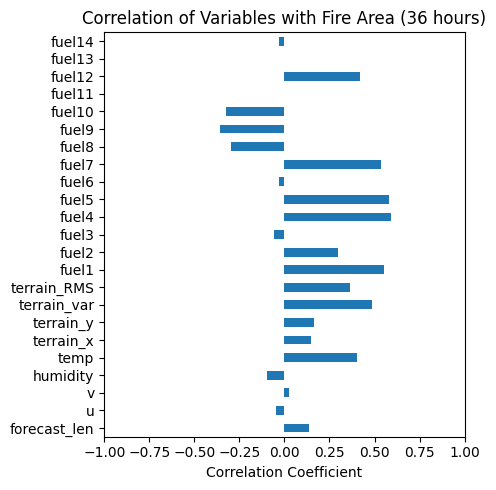

In [87]:
fire_area_corr = df.corr().iloc[0, 1:]

plt.figure(figsize=(5, 5))
fire_area_corr.plot(kind='barh')
plt.xlim(-1, 1)
plt.title("Correlation of Variables with Fire Area (36 hours)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

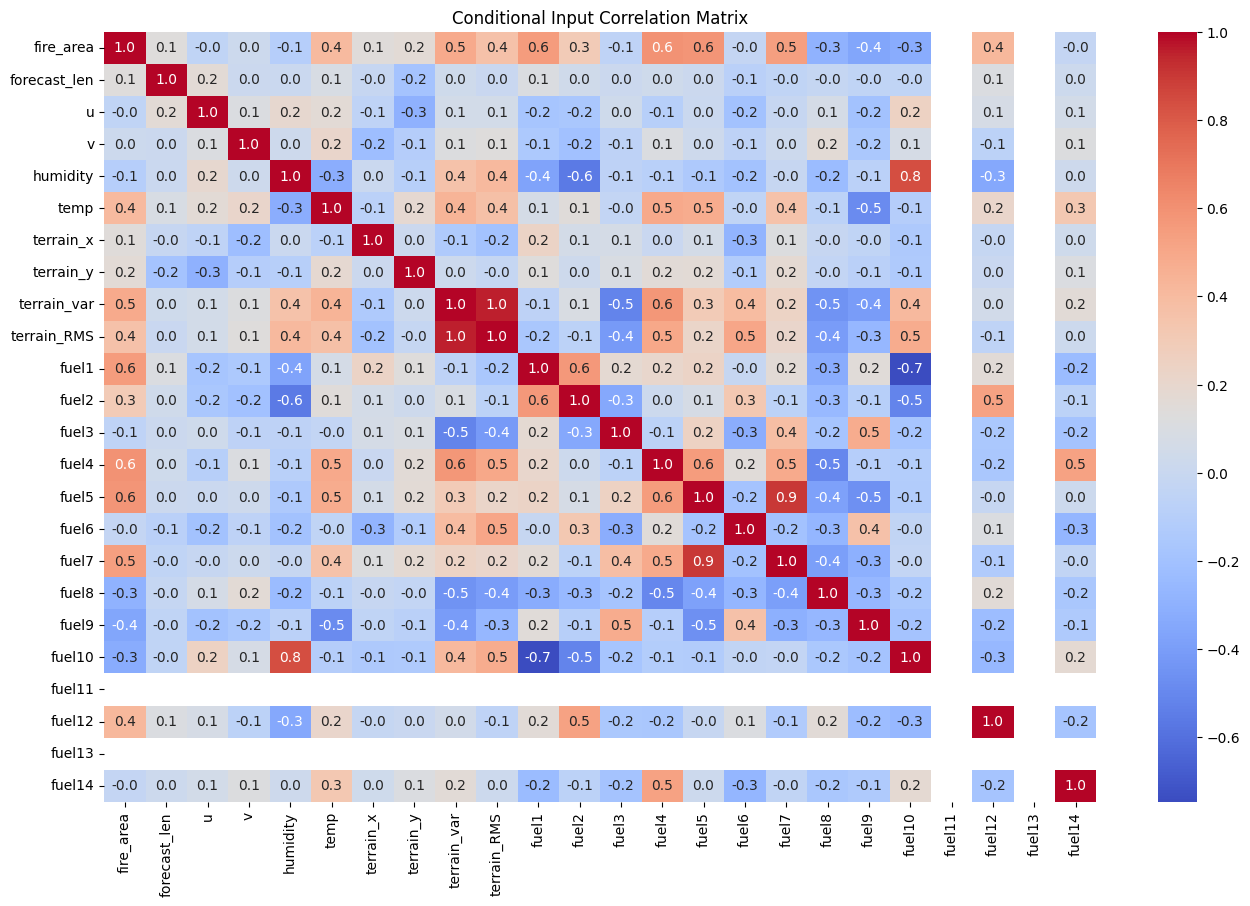

In [88]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), annot=True, fmt="0.1f", cmap="coolwarm")
plt.title("Conditional Input Correlation Matrix")
plt.show()

In [89]:
u,v = df['u'],df['v']
u = (u*28)-14
v = (v*28)-14
wind_speed = np.sqrt(u**2 + v**2)
print(wind_speed.shape)

fuel2 = df['fuel2']
fuel12 = df['fuel12']
humidity = df['humidity']

filtered_real_fire_area = filtered_testing_data[:,0]
print(filtered_real_fire_area.shape)

filtered_pred_fire_area = pred[indices]
print(filtered_pred_fire_area.shape)

(123,)
(123,)
(123, 1)


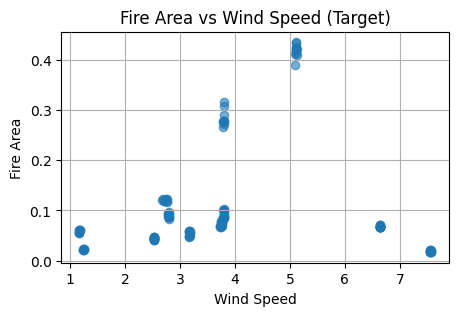

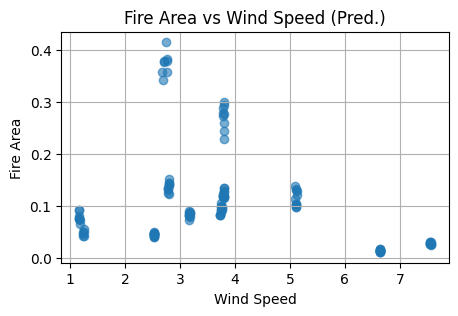

In [90]:
plt.figure(figsize=(5, 3))
plt.scatter(wind_speed, filtered_real_fire_area, alpha=0.6)
plt.xlabel('Wind Speed')
plt.ylabel('Fire Area')
plt.title('Fire Area vs Wind Speed (Target)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(wind_speed, filtered_pred_fire_area, alpha=0.6)
plt.xlabel('Wind Speed')
plt.ylabel('Fire Area')
plt.title('Fire Area vs Wind Speed (Pred.)')
plt.grid(True)
plt.show()

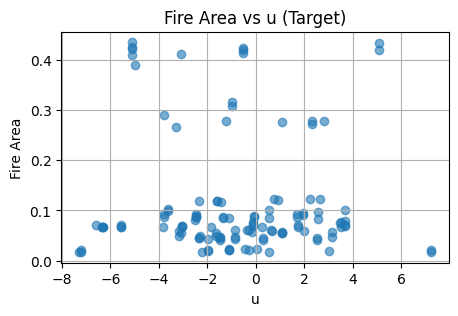

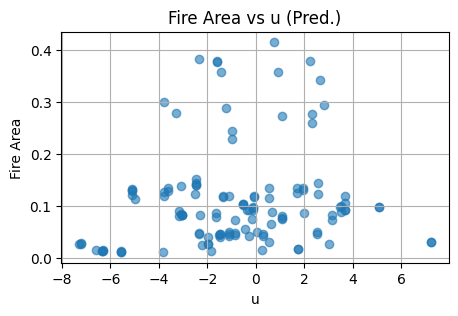

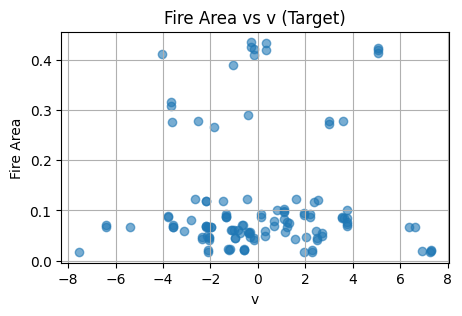

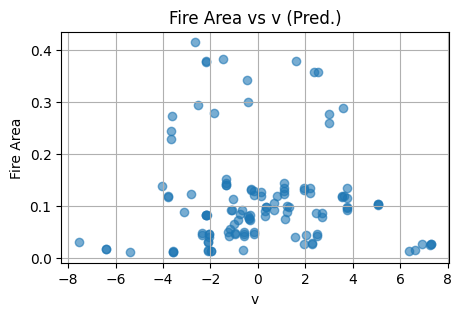

In [91]:
plt.figure(figsize=(5, 3))
plt.scatter(u, filtered_real_fire_area, alpha=0.6)
plt.xlabel('u')
plt.ylabel('Fire Area')
plt.title('Fire Area vs u (Target)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(u, filtered_pred_fire_area, alpha=0.6)
plt.xlabel('u')
plt.ylabel('Fire Area')
plt.title('Fire Area vs u (Pred.)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(v, filtered_real_fire_area, alpha=0.6)
plt.xlabel('v')
plt.ylabel('Fire Area')
plt.title('Fire Area vs v (Target)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(v, filtered_pred_fire_area, alpha=0.6)
plt.xlabel('v')
plt.ylabel('Fire Area')
plt.title('Fire Area vs v (Pred.)')
plt.grid(True)
plt.show()

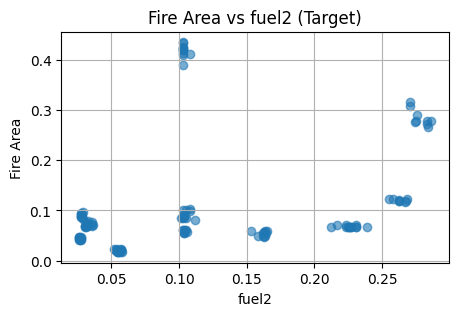

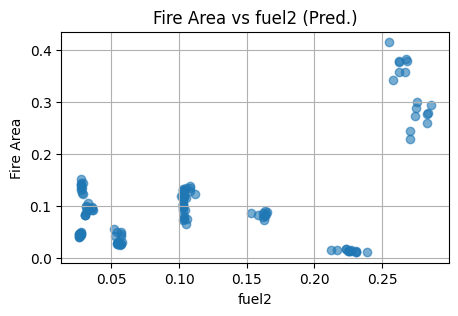

In [92]:
plt.figure(figsize=(5, 3))
plt.scatter(fuel2, filtered_real_fire_area, alpha=0.6)
plt.xlabel('fuel2')
plt.ylabel('Fire Area')
plt.title('Fire Area vs fuel2 (Target)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(fuel2, filtered_pred_fire_area, alpha=0.6)
plt.xlabel('fuel2')
plt.ylabel('Fire Area')
plt.title('Fire Area vs fuel2 (Pred.)')
plt.grid(True)
plt.show()

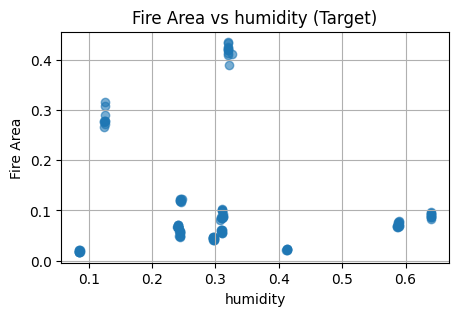

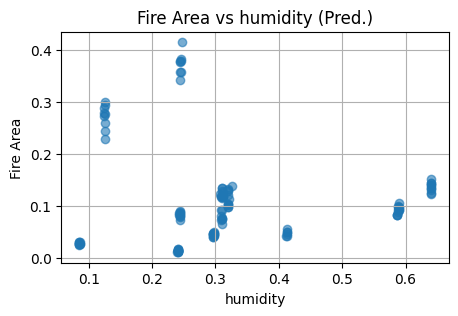

In [93]:
plt.figure(figsize=(5, 3))
plt.scatter(humidity, filtered_real_fire_area, alpha=0.6)
plt.xlabel('humidity')
plt.ylabel('Fire Area')
plt.title('Fire Area vs humidity (Target)')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(humidity, filtered_pred_fire_area, alpha=0.6)
plt.xlabel('humidity')
plt.ylabel('Fire Area')
plt.title('Fire Area vs humidity (Pred.)')
plt.grid(True)
plt.show()